# EDA Decission Tree

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split
import pickle

## Definición del problema

>### Análisis de sentimientos
>Los modelos Naive Bayes son muy útiles cuando queremos analizar sentimientos, clasificar textos en tópicos o recomendaciones, ya que las características de estos desafíos cumplen muy bien con los supuestos teóricos y metodológicos del modelo.



## Recopilación de datos

In [3]:
df = pd.read_csv('/workspaces/adamcn10-intro-ml/data/raw/playstore_reviews.csv')
df.head()

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0


## Análisis Descriptivo

In [4]:
df.shape

(891, 3)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   package_name  891 non-null    object
 1   review        891 non-null    object
 2   polarity      891 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 21.0+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
polarity,891.0,0.344557,0.47549,0.0,0.0,0.0,1.0,1.0


In [7]:
df.nunique()

package_name     23
review          891
polarity          2
dtype: int64

## Limpieza de datos

### Eliminar Duplicados

In [8]:
df.duplicated().sum()

np.int64(0)

### Eliminar información irrelevante

>A priori no vemos ningun dato irrelevante

## Análisis de Variables

>No podemos analizar los datos de los comentarios, por lo que los analisis serán de las aplicaciones comentadas y la polaridad de estos

### Análisis de Variables Univariable

<function matplotlib.pyplot.show(close=None, block=None)>

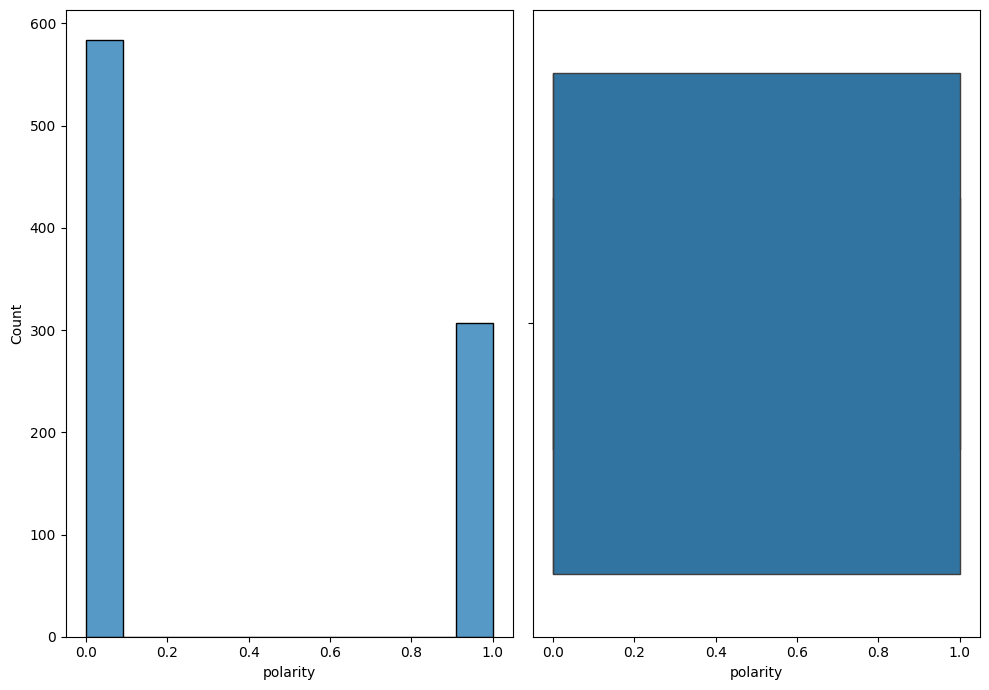

In [12]:
fig, axis = plt.subplots(1, 2, figsize=(10, 7))

sns.histplot(ax=axis[0], data=df, x="polarity")
sns.boxplot(ax=axis[1], data=df, x="polarity")

plt.tight_layout()
plt.show

>Vemos como se distribuyen y las formas que tienen los datos de polaridad

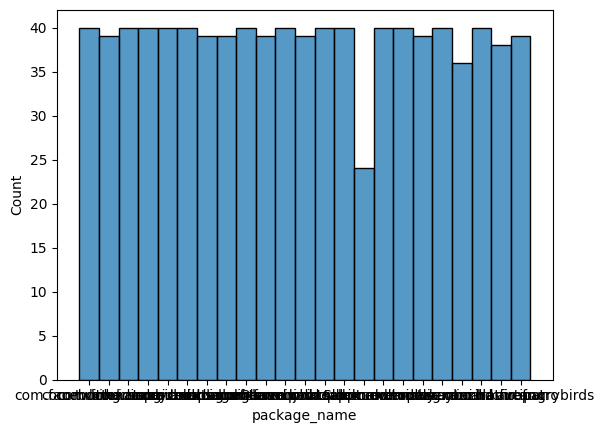

In [ ]:
sns.histplot(data=df, x="package_name")
plt.show()

> Vemos que los comentarios estan distribuidos de manera más o menos uniforme escepto por una app

### Análisis de Variables Multivariable

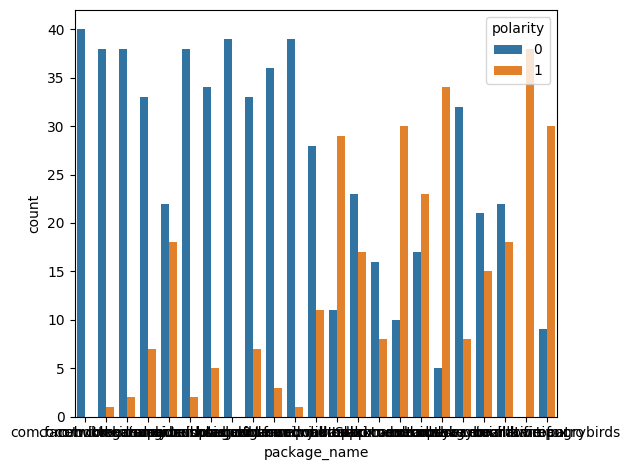

In [16]:
sns.countplot(data=df, x="package_name", hue='polarity')
plt.tight_layout()
plt.show()


>Vemos que hay aplicaciones con comentarios completamente o mayoritariamente negativos y otras con mayoritariamente o completamente positivos.

In [18]:
df['package_number'] = pd.factorize(df['package_name'])[0]

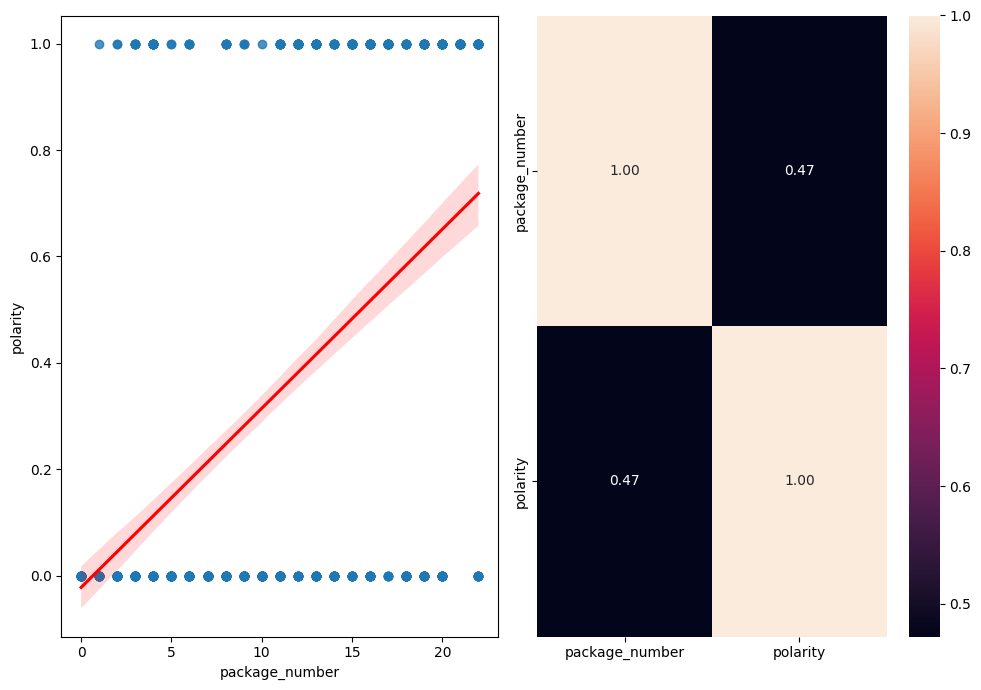

In [22]:
corr = df[['package_number', 'polarity']].corr()

fig, axis = plt.subplots(1, 2, figsize=(10, 7))

sns.regplot(ax=axis[0], data=df, x="package_number", y="polarity", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1], data=corr, annot=True, fmt=".2f")

plt.tight_layout()
plt.show()

>Vemos que la aplicación en si misma influye claramente en la positividad o negatividadd de los comentarios

## Ingeniería de Características

### Outliers

In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
polarity,891.0,0.344557,0.475490,0.0,0.0,0.0,1.0,1.0
package_number,891.0,10.892256,6.667686,0.0,5.0,11.0,17.0,22.0


<function matplotlib.pyplot.show(close=None, block=None)>

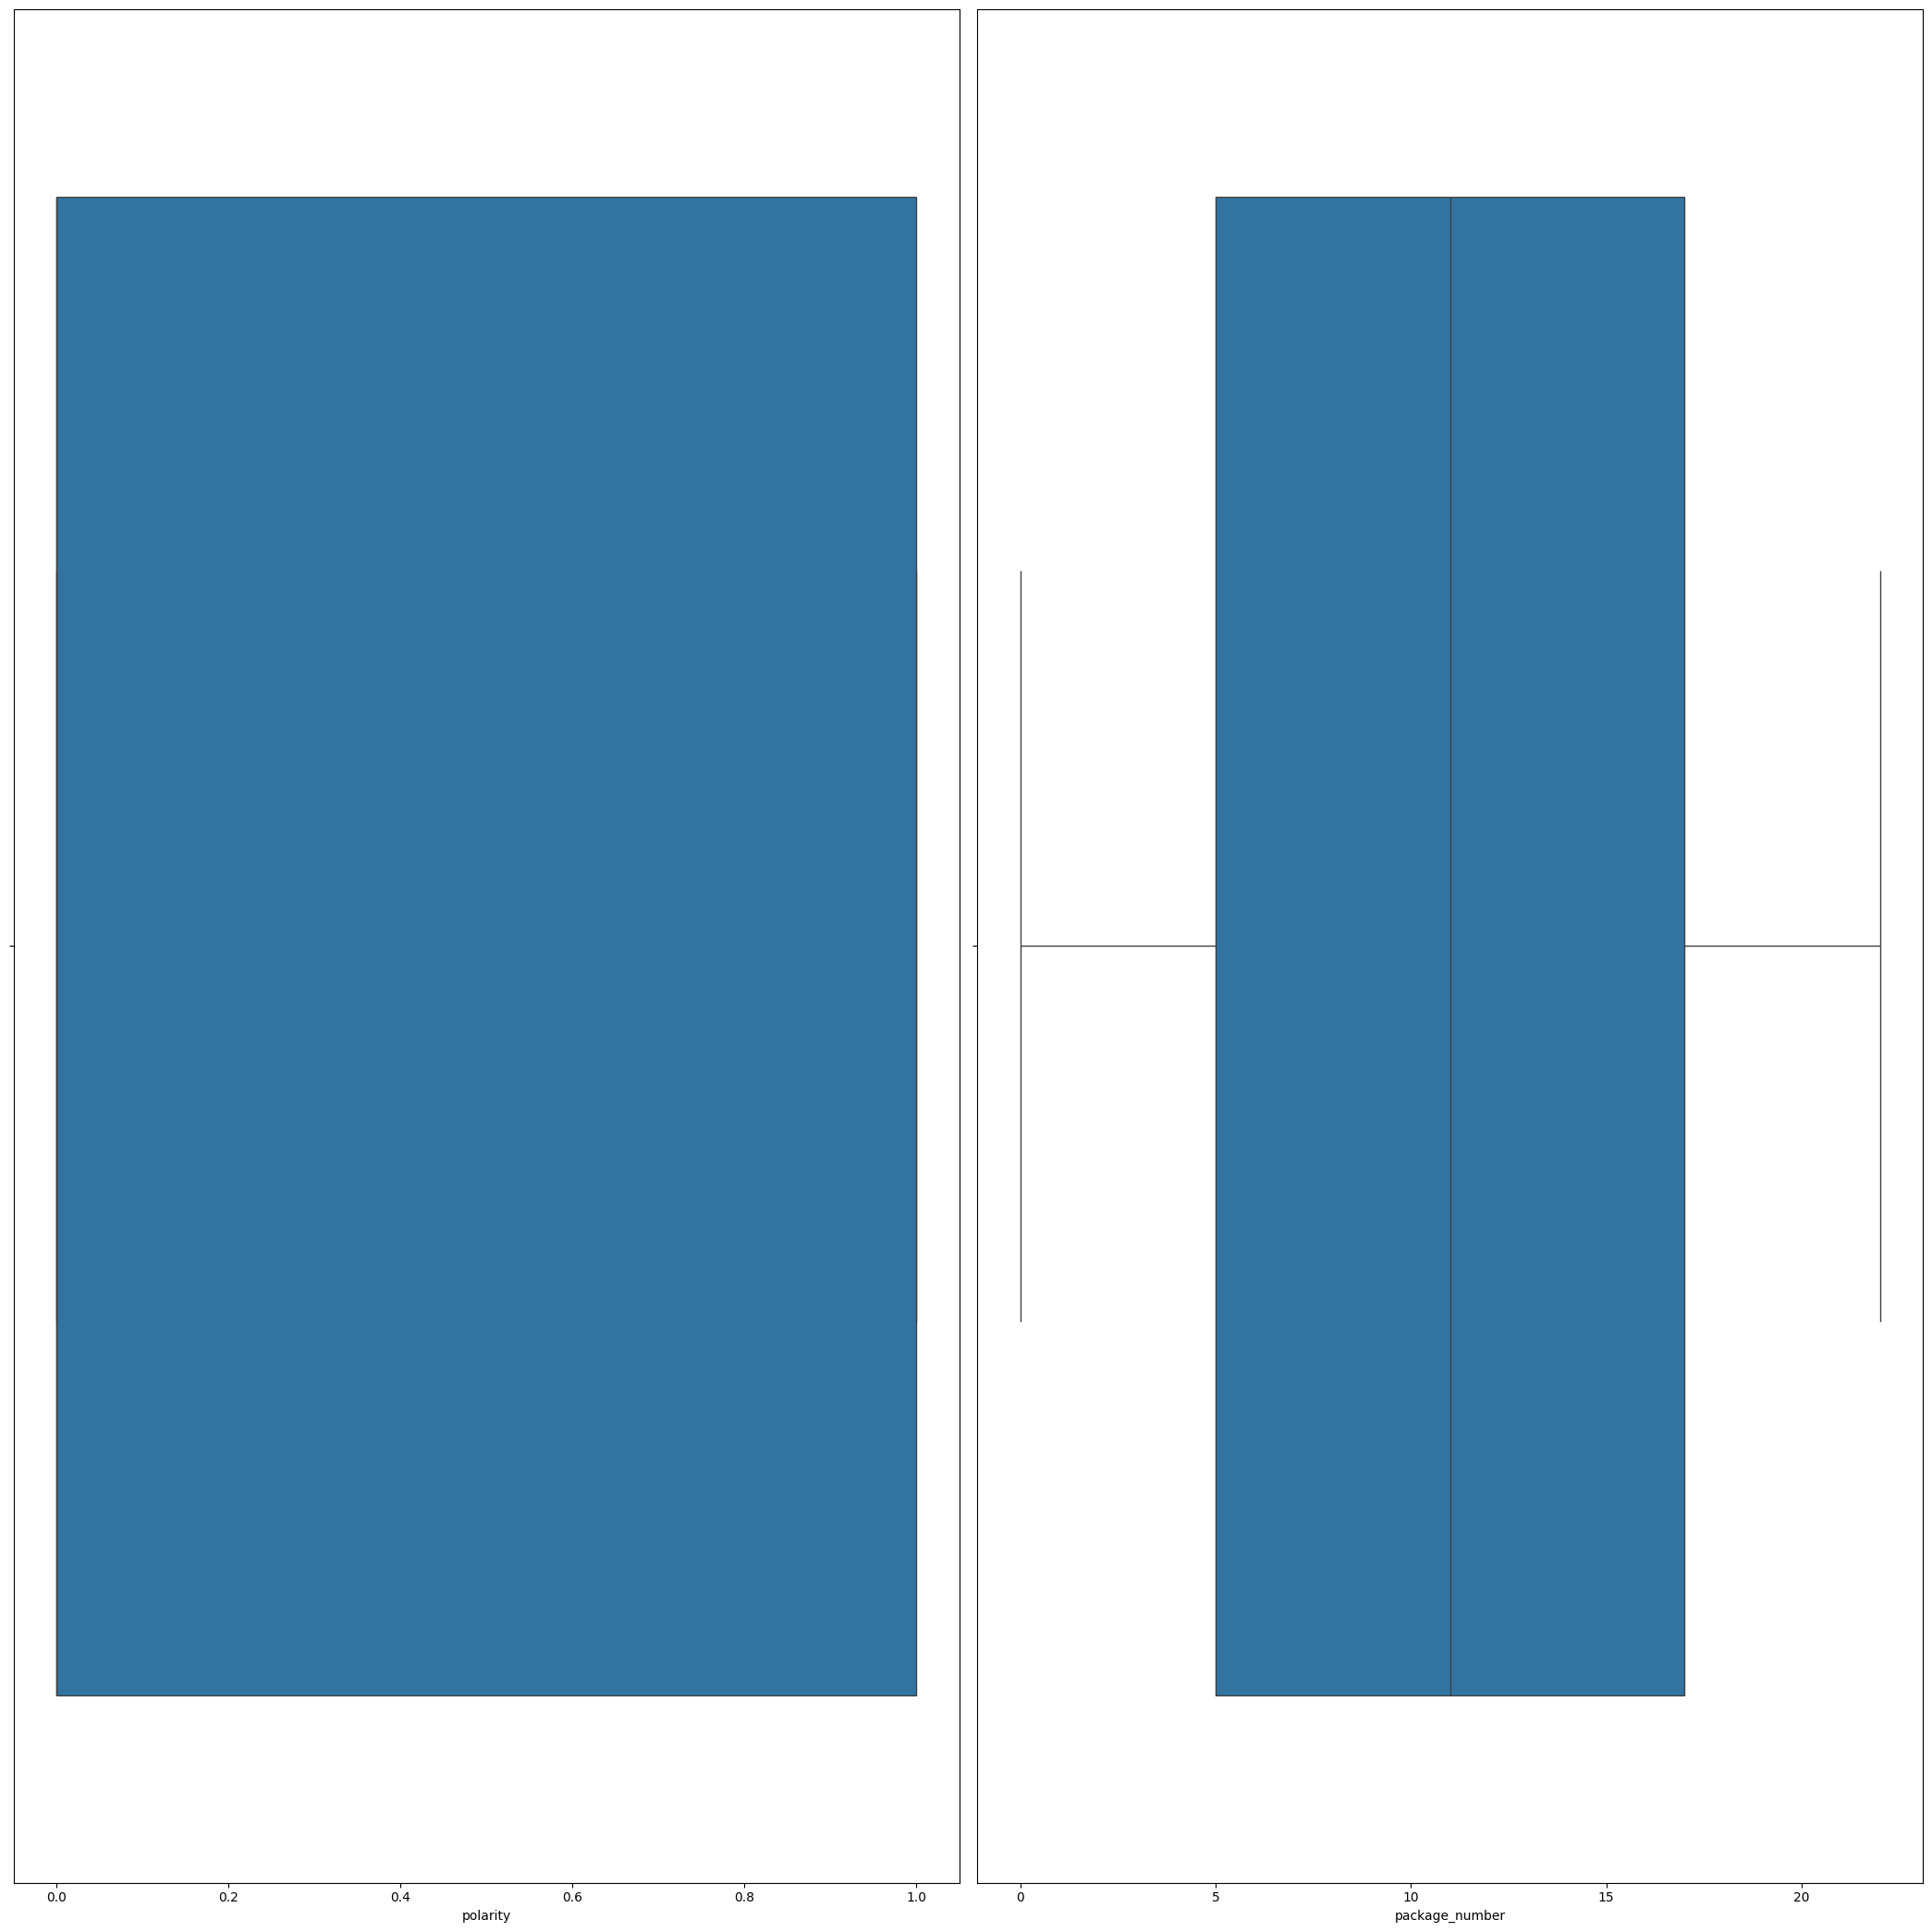

In [25]:
fig, axis = plt.subplots(1, 2, figsize=(21, 21))

sns.boxplot(ax=axis[0], data=df, x="polarity")
sns.boxplot(ax=axis[1], data=df, x="package_number")


plt.tight_layout()
plt.show

>No vemos outliers en ninguno de los dos casos

In [30]:
df.drop(['package_number'], axis=1, inplace=True)

### Faltantes

In [31]:
df.isnull().sum() / df.shape[0]

package_name    0.0
review          0.0
polarity        0.0
dtype: float64

In [32]:
df.isnull().sum().sort_values(ascending=False)

package_name    0
review          0
polarity        0
dtype: int64

>No vemos valores nulos en ninguna columna

### Inferencia de nuevas características

>No veo nuevas caracteristicas que se deban generar.

## Split

>Hacemos el split con los datos

In [34]:
X = df.drop("polarity", axis=1)
y = df["polarity"]

X_train, X_test, y_train, y_test_ = train_test_split(X, y, 
                                                     test_size=0.2, 
                                                     random_state=25)

## Encoding & Scaling

### Encoding

>No hace falta encoding ya que todas las variables son numéricas

### Scaling

>No hace falta escalado porque aplicaremos arboles de decisión y a estos no les afecta que los datos esten en diferentes escalas

## Guardado de Datos